# Synthetic Model and Gravity Anomaly Generation

First Importing Useful Libraries in Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
from numpy import asarray
import random

Defining Model Parameters for Two Prism Bodies in subsurface

In [2]:
G = 6.67*(10**-6) #Gravitational constant in SI

D1= 0.3 #Lower end depth of the 1st prism in km
d1=0.001 #Upper end depth of the 1st prism in meter
m1=30.1 #width of the 1st prism in meter
rho1=2.7 #density of the 1st prism in gm/cc
A1= -50.1 #Co-ordinate of 1st prism in horizontal(X) direction

D2= 0.5 #Lower end depth of the 2nd prism in km
d2=0.001 #Upper end depth of the 2nd prism in meter
m2=30.1 #width of the 2nd prism in meter
rho2=2.2 #density of the 2nd prism in gm/cc
A2= 50.1 #Co-ordinate of 2nd prism in horizontal(X) direction

NUM_INIT_POINTS = 50 # number of observation points
x=np.linspace(-75,75,50) #Station measurement points

Calculation of summed gravity anomaly for the prism bodies along a horizontal profile with above mentioned station spacing.

In [3]:
#Calculating for 1st prism
r1_1=(((x-A1)+(0.5*m1))**2)+((d1)**2)
r2_1=(((x-A1)+(0.5*m1))**2)+((D1*1000)**2)
r3_1=(((x-A1)-(0.5*m1))**2)+((d1)**2)
r4_1=(((x-A1)-(0.5*m1))**2)+((D1*1000)**2)
f1_1=np.arctan((x-A1+(0.5*m1))/(D1*1000))-np.arctan((x-A1-(0.5*m1))/(D1*1000))
f2_1=np.arctan((x-A1+(0.5*m1))/d1)-np.arctan((x-A1-(0.5*m1))/d1)
f3_1=0.5*(x-A1)*(np.log10((r2_1*r3_1)/(r1_1*r4_1)))
f4_1=0.25*m1*(np.log10((r2_1*r4_1)/(r1_1*r3_1)))
f_1=((D1*1000)*f1_1)-(d1*f2_1)+f3_1+f4_1
y1=2*G*rho1*1000*f_1 #gravity anomaly value of 1st prism in miligal without noise

#Calculating for 2nd prism
r1_2=(((x-A2)+(0.5*m2))**2)+((d2)**2)
r2_2=(((x-A2)+(0.5*m2))**2)+((D2*1000)**2)
r3_2=(((x-A2)-(0.5*m2))**2)+((d2)**2)
r4_2=(((x-A2)-(0.5*m2))**2)+((D2*1000)**2)
f1_2=np.arctan((x-A2+(0.5*m2))/(D2*1000))-np.arctan((x-A2-(0.5*m2))/(D2*1000))
f2_2=np.arctan((x-A2+(0.5*m2))/d2)-np.arctan((x-A2-(0.5*m2))/d2)
f3_2=0.5*(x-A2)*(np.log10((r2_2*r3_2)/(r1_2*r4_2)))
f4_2=0.25*m2*(np.log10((r2_2*r4_2)/(r1_2*r3_2)))
f_2=((D2*1000)*f1_2)-(d2*f2_2)+f3_2+f4_2
y2=2*G*rho2*1000*f_2 #gravity anomaly value of 2nd prism in miligal without noise

y=y1+y2 #Summed Gravity Anomaly in miligal

Adding Gaussian noise, Random Walk noise, Salt & Pepper noise and Systematic noise in the calculated gravity anomaly to achieve the real world scenario in some extent as,
**Gaussian Noise:** due to Measurement errors, random environment factor.
**Random Walk Noise:** due to Slow drift in instruments, Temparature fluctuations.
**Salt & Pepper Noise:** due to outliers in data collection process or digitization.
**Systematic Noise:** due to environmental factors (gravitational pull from nearby structures) or incorrect datum.

In [4]:
import tensorflow as tf
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
#Generate Gaussian Noise
gaussian_noise = np.random.normal(0, 0.05, size=x.shape)
# Generate Random Walk Noise
# Step size is drawn from a normal distribution
random_steps = np.random.normal(0, 0.01, size=x.shape)
random_walk_noise = np.cumsum(random_steps)  # Cumulative sum to simulate random walk
#Salt & Pepper noise
salt_prob=0.05 #probability of salt(white) noise
pepper_prob=0.05 #probability of pepper(black) noise
noise_level=0.02 # 2% Salt & Pepper noise
salt_and_pepper_noise = (np.random.choice([0,1,-1],size=x.shape,p=[1 - (salt_prob + pepper_prob),salt_prob,pepper_prob]))*noise_level
#Systematic Noise (Assuming polynomial pattern of systematic noise with distance(x))
a,b,c=0.001,0.0001,0.001 #Co-efficients of Quadratic & Cubic terms
systematic_noise_level=0.01 # 1% Systematic noise
systematic_noise = systematic_noise_level*((a*((x*0.1)**2))+(b*((x*0.1)**3))+c)

#Adding noise to the gravity anomaly data
y_true = y + gaussian_noise+salt_and_pepper_noise+systematic_noise+ random_walk_noise

Plotting the generated gravity anomaly curve along with the Forward synthetic model

(np.float64(0.0), np.float64(0.3420070267896348), np.float64(1.0), np.float64(1.0))


[None, None, None, None, None, None]

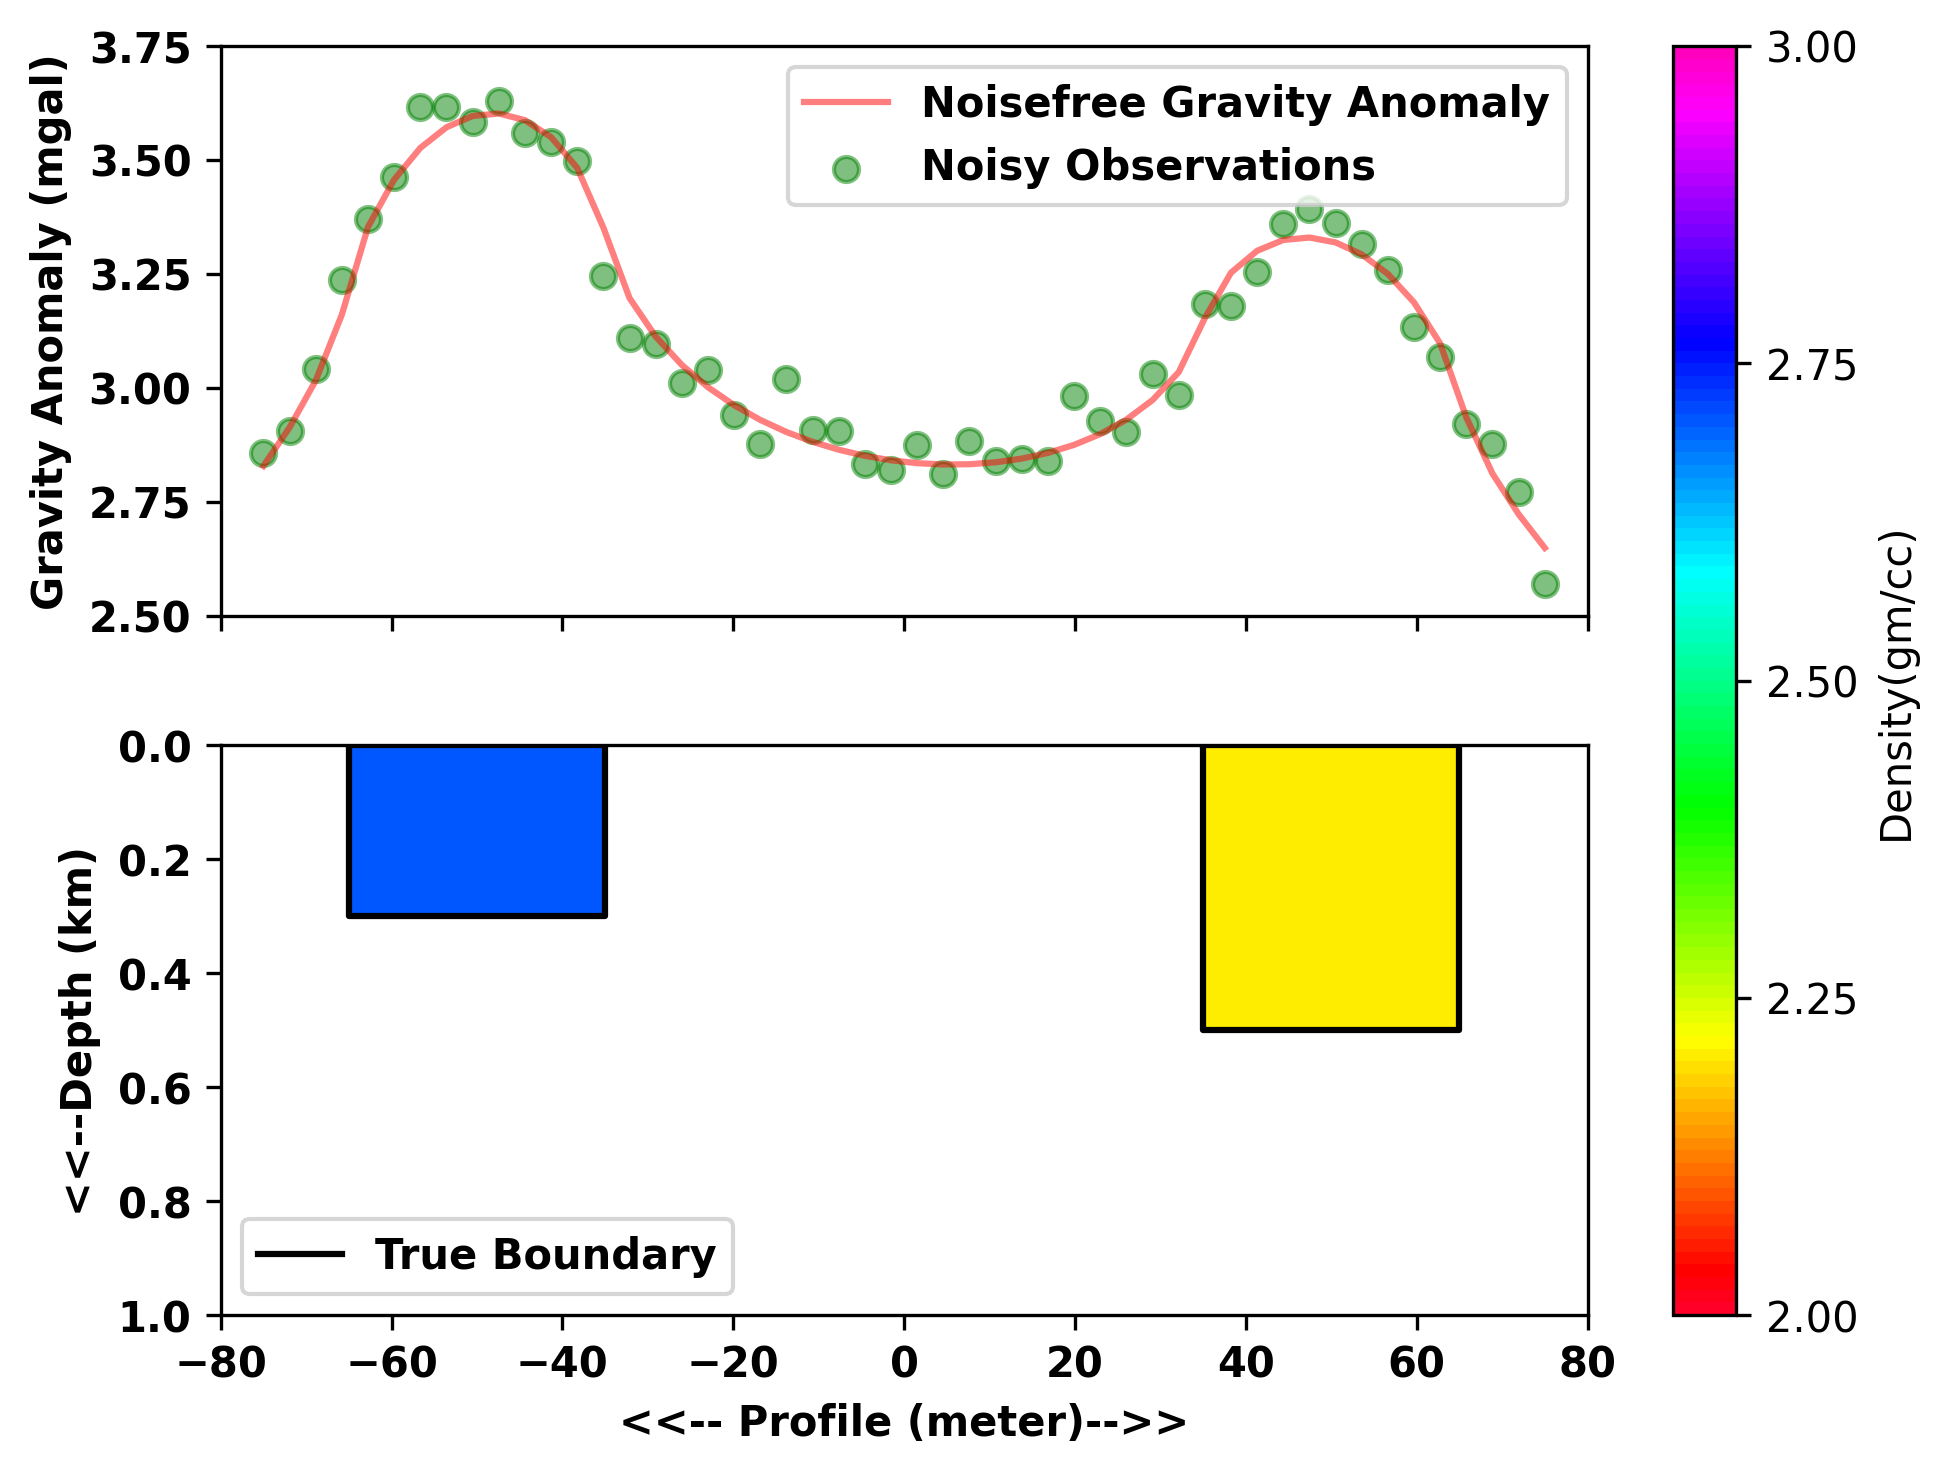

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

#import matplotlib.pyplot as plt
fig, axs = plt.subplots(2)
fig.tight_layout(pad=1)
fig.dpi=300
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3
minimum_V=2
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)
index_value_V1 = (rho1-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
print(color_V1)
index_value_V2 = (rho2-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')
for i in range(1):
    coord1 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
    coord2 = [[35,0], [65,0], [65,0.5], [35,0.5]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    axs[1].plot(xs1,ys1,'k')
    axs[1].fill(xs1, ys1, facecolor=color_V1)
    axs[1].plot(xs2,ys2,'k')
    axs[1].fill(xs2, ys2, facecolor=color_V2)
    axs[1].set_xlim(-80,80)
    axs[1].set_ylim(1,0)
    legend_properties = {'weight':'bold'}
    axs[1].legend(['True Boundary'],prop=legend_properties)
    axs[1].set_xlabel('<<-- Profile (meter)-->>',fontsize=10,weight='bold')
    axs[1].set_ylabel("<<--Depth (km)",fontsize=10,weight='bold')
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')
axs[0].plot(x,y, alpha=0.5, c='red')
axs[0].scatter(x, y_true, alpha=0.5, c='g', marker='o')
legend_properties = {'weight':'bold'}
axs[0].legend(['Noisefree Gravity Anomaly','Noisy Observations'],prop=legend_properties)
axs[0].set_ylabel("Gravity Anomaly (mgal)",fontsize=10,weight='bold')
axs[0].set_xlim(-80,80)
axs[0].set_ylim(2.5,3.75)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[0].get_yticklabels(), weight='bold')

# Inversion using Gradient Descent Approach

Defining Two functions here.                
**Mean Squared Error function:** to calculate the Objective or Cost Function.

**Gradient Descent Function:** Gradient descent is a popular iterative optimization algorithm used to find the minimum of a function.It is a local optimization technique. The main goal of this inversion method is to find minimum of the Objective function.
The following steps are followed for this inversion technique in a iterative approach:

1. Calculate the gradient of the objective function with respect to the model parameters.
2. Choose an initial guess for the parameter values (Random values within the defined real geologic range)
3. Update the parameters in the opposite direction of the gradient to reduce the value of the objective function.
Updated model parameter value= Current value - learning_rate * output of step1.        
(We basically change learning rate in a iterative manner and see for which case the best result as well as fast calculation is get)
4. Repeate steps 2-4 until a stopping criterion is met that is stopping thresold value achieved.

In [6]:
INITIAL_DENSITY1 = random.uniform(2,3)
INITIAL_DEPTH1 = random.uniform(0,0.7)
INITIAL_DENSITY2 =  random.uniform(2,3)
INITIAL_DEPTH2 = random.uniform(0,0.7)

In [ ]:
def mean_squared_error(y_true, y_predicted):

    # Calculating the loss or cost
    cost = np.sum((y_true-y_predicted)**2) / len(y_true)
    return cost

#Mean Squared Error (Objective Function)
def objective(rho_v1,D_v1,rho_v2,D_v2):
    # Calculating the loss or cost
    y_predicted = G*1000*rho_v1*(((x+(m1/2))*np.log10(1+(((D_v1*1000)/(x+(m1/2)))**2)))-((x-(m1/2))*(np.log10(1+(((D_v1*1000)/(x-(m1/2)))**2))))+(2*(D_v1*1000)*((np.arctan((x+(m1/2))/(D_v1*1000)))-(np.arctan((x-(m1/2))/(D_v1*1000))))))+G*1000*rho_v2*(((x+(m2/2))*np.log10(1+(((D_v2*1000)/(x+(m2/2)))**2)))-((x-(m2/2))*(np.log10(1+(((D_v2*1000)/(x-(m2/2)))**2))))+(2*(D_v2*1000)*((np.arctan((x+(m2/2))/(D_v2*1000)))-(np.arctan((x-(m2/2))/(D_v2*1000))))))
    cost = np.sum((y_true-y_predicted)**2) / len(y_true)
    return cost

# Gradient Descent Function. Here iterations, learning_rate, stopping_threshold are hyperparameters that can be tuned
def gradient_descent(G,x,A1,m1,d1,A2,m2,d2,y, iterations, learning_rate =0.01,
                     stopping_threshold = 0):

    # Initializing weight, bias, learning rate and iterations
    current_density1 = INITIAL_DENSITY1  #enter initial guess of the prism1 density
    current_depth1 = INITIAL_DEPTH1  #enter initial guess of the prism1 depth
    current_density2 = INITIAL_DENSITY2  #enter initial guess of the prism2 density
    current_depth2 = INITIAL_DEPTH2 #enter initial guess of the prism2 depth
    iterations = iterations #number of times the loop will be iterated
    learning_rate = learning_rate #learning rate fixed by the user, it should not be too small for greater computational time nor too large so that the problem stucked into nearby local minima
    n = float(len(x))

    costs = []  #defining cost matrix. it will be updated with a new value at each iteration.
    densities_1 = [] #defining density matrix of prism1. it will be updated with a new value at each iteration.
    depths_1=[] #defining depth matrix of prism1. it will be updated with a new value at each iteration.
    densities_2 = [] #defining density matrix of prism2. it will be updated with a new value at each iteration.
    depths_2=[] #defining depth matrix of prism2. it will be updated with a new value at each iteration.
    I= [] #iteration matrix
    previous_cost = None

    # Estimation of optimal parameters
    for i in range(iterations):


        # Making predictions at that particular iteration
        y1_predicted=2*G*current_density1*1000*(((current_depth1*1000)*(np.arctan((x-A1+(0.5*m1))/(current_depth1*1000))-np.arctan((x-A1-(0.5*m1))/(current_depth1*1000))))-(d1*(np.arctan((x-A1+(0.5*m1))/d1)-np.arctan((x-A1-(0.5*m1))/d1)))+(0.5*(x-A1)*(np.log10((((((x-A1)+(0.5*m1))**2)+((current_depth1*1000)**2))*((((x-A1)-(0.5*m1))**2)+((d1)**2)))/(((((x-A1)+(0.5*m1))**2)+((d1)**2))*((((x-A1)-(0.5*m1))**2)+((current_depth1*1000)**2))))))+(0.25*m1*(np.log10((((((x-A1)+(0.5*m1))**2)+((current_depth1*1000)**2))*((((x-A1)-(0.5*m1))**2)+((current_depth1*1000)**2)))/(((((x-A1)+(0.5*m1))**2)+((d1)**2))*((((x-A1)-(0.5*m1))**2)+((d1)**2)))))))
        y2_predicted=2*G*current_density2*1000*(((current_depth2*1000)*(np.arctan((x-A2+(0.5*m2))/(current_depth2*1000))-np.arctan((x-A2-(0.5*m2))/(current_depth2*1000))))-(d2*(np.arctan((x-A2+(0.5*m2))/d2)-np.arctan((x-A2-(0.5*m2))/d2)))+(0.5*(x-A2)*(np.log10((((((x-A2)+(0.5*m2))**2)+((current_depth2*1000)**2))*((((x-A2)-(0.5*m2))**2)+((d2)**2)))/(((((x-A2)+(0.5*m2))**2)+((d2)**2))*((((x-A2)-(0.5*m2))**2)+((current_depth2*1000)**2))))))+(0.25*m2*(np.log10((((((x-A2)+(0.5*m2))**2)+((current_depth2*1000)**2))*((((x-A2)-(0.5*m2))**2)+((current_depth2*1000)**2)))/(((((x-A2)+(0.5*m2))**2)+((d2)**2))*((((x-A2)-(0.5*m2))**2)+((d2)**2)))))))
        y_predicted = y1_predicted+y2_predicted
        # Calculating the current cost at that particular iteration
        current_cost = mean_squared_error(y, y_predicted)

        # If the change in cost is less than or equal to stopping_threshold we stop the gradient descent
        if previous_cost is not None and previous_cost <= current_cost:
            break

        previous_cost = current_cost

        costs.append(current_cost) #adding new updated value of cost to the cost matrix
        densities_1.append(current_density1) #adding new updated value of density of prism 1 to the density matrix
        densities_2.append(current_density2) #adding new updated value of density of prism 2 to the density matrix
        depths_1.append(current_depth1) #adding new updated value of depth of prism 1 to the depth matrix
        depths_2.append(current_depth2) #adding new updated value of depth of prism 2 to the depth matrix
        I.append(i)

        # Calculating the gradients
        R2_1= ((x-A1+ 0.5*m1)**2)+(current_depth1*1000)**2
        R4_1= ((x-A1- 0.5*m1)**2)+(current_depth1*1000)**2
        R2_2= ((x-A2+ 0.5*m2)**2)+(current_depth2*1000)**2
        R4_2= ((x-A2- 0.5*m2)**2)+(current_depth2*1000)**2
        density_derivative1 = -(2/n)*sum(2*G*1000*(((current_depth1*1000)*(np.arctan((x-A1+(0.5*m1))/(current_depth1*1000))-np.arctan((x-A1-(0.5*m1))/(current_depth1*1000))))-(d1*(np.arctan((x-A1+(0.5*m1))/d1)-np.arctan((x-A1-(0.5*m1))/d1)))+(0.5*(x-A1)*(np.log10((((((x-A1)+(0.5*m1))**2)+((current_depth1*1000)**2))*((((x-A1)-(0.5*m1))**2)+((d1)**2)))/(((((x-A1)+(0.5*m1))**2)+((d1)**2))*((((x-A1)-(0.5*m1))**2)+((current_depth1*1000)**2))))))+(0.25*m1*(np.log10((((((x-A1)+(0.5*m1))**2)+((current_depth1*1000)**2))*((((x-A1)-(0.5*m1))**2)+((current_depth1*1000)**2)))/(((((x-A1)+(0.5*m1))**2)+((d1)**2))*((((x-A1)-(0.5*m1))**2)+((d1)**2)))))))*(y-y1_predicted))
        depth_derivative1 = -(2/n)*sum((y-y1_predicted)*(2*G*1000*current_density1*((np.arctan((x-A1+(0.5*m1))/(current_depth1*1000))-np.arctan((x-A1-(0.5*m1))/(current_depth1*1000)))+(current_depth1*1000)*(((x-A1-(0.5*m1))/(((x-A1-(0.5*m1))**2)+1))-((x-A1+(0.5*m1))/(((x-A1+(0.5*m1))**2)+1)))+(0.5*(x-A1)*2*(current_depth1*1000)*((1/R2_1)-(1/R4_1)))+(0.25*m1*2*(current_depth1*1000)*((1/R2_1)+(1/R4_1))))))
        density_derivative2 = -(2/n)*sum(2*G*1000*(((current_depth2*1000)*(np.arctan((x-A2+(0.5*m2))/(current_depth2*1000))-np.arctan((x-A2-(0.5*m2))/(current_depth2*1000))))-(d2*(np.arctan((x-A2+(0.5*m2))/d2)-np.arctan((x-A2-(0.5*m2))/d2)))+(0.5*(x-A2)*(np.log10((((((x-A2)+(0.5*m2))**2)+((current_depth2*1000)**2))*((((x-A2)-(0.5*m2))**2)+((d2)**2)))/(((((x-A2)+(0.5*m2))**2)+((d2)**2))*((((x-A2)-(0.5*m2))**2)+((current_depth2*1000)**2))))))+(0.25*m2*(np.log10((((((x-A2)+(0.5*m2))**2)+((current_depth2*1000)**2))*((((x-A2)-(0.5*m2))**2)+((current_depth2*1000)**2)))/(((((x-A2)+(0.5*m2))**2)+((d2)**2))*((((x-A2)-(0.5*m2))**2)+((d2)**2)))))))*(y-y2_predicted))
        depth_derivative2 = -(2/n)*sum((y-y2_predicted)*(2*G*1000*current_density2*((np.arctan((x-A2+(0.5*m2))/(current_depth2*1000))-np.arctan((x-A2-(0.5*m2))/(current_depth2*1000)))+(current_depth2*1000)*(((x-A2-(0.5*m2))/(((x-A2-(0.5*m2))**2)+1))-((x-A2+(0.5*m2))/(((x-A2+(0.5*m2))**2)+1)))+(0.5*(x-A2)*2*(current_depth2*1000)*((1/R2_2)-(1/R4_2)))+(0.25*m2*2*(current_depth2*1000)*((1/R2_2)+(1/R4_2))))))



        #calculation of new updated parameters
        current_density1 = current_density1 - (learning_rate * density_derivative1)
        current_depth1 = current_depth1 - (learning_rate * depth_derivative1)
        current_density2 = current_density2 - (learning_rate * density_derivative2)
        current_depth2 = current_depth2 - (learning_rate * depth_derivative2)

        # Printing the updated parameters for each iteration
        print(f"Iteration {i+1}: Cost {current_cost}, Density_1 \
        {current_density1},Depth_1  {current_depth1},Density_2  {current_density2},Depth_2  {current_depth2}")


    # Visualizing the density vs cost for prism 1 for all iterations
    plt.subplot(1,5,1)
    plt.plot(densities_1, costs)
    plt.scatter(densities_1, costs, marker='o', color='red')
    plt.title("Cost vs Densities of Prism1",fontsize=10,weight='bold')
    plt.ylabel("Cost",fontsize=10,weight='bold')
    plt.xlabel("Density",fontsize=10,weight='bold')
    #plt.xlim(1.5,3)
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')
    plt.show()


    # Visualizing the density vs cost for prism 2 for all iterations
    plt.subplot(1,5,2)
    plt.plot(densities_2, costs)
    plt.scatter(densities_2, costs, marker='o', color='red')
    plt.title("Cost vs Densities of Prism2",fontsize=10,weight='bold')
    plt.ylabel("Cost",fontsize=10,weight='bold')
    plt.xlabel("Density",fontsize=10,weight='bold')
    #plt.xlim(1.5,3)
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')
    plt.show()

    # Visualizing the depth vs cost for prism 1 for all iterations
    plt.subplot(1,5,3)
    plt.plot(depths_1, costs)
    plt.scatter(depths_1, costs, marker='o', color='red')
    plt.title("Cost vs Depths of Prism1",fontsize=10,weight='bold')
    plt.ylabel("Cost",fontsize=10,weight='bold')
    plt.xlabel("Depth",fontsize=10,weight='bold')
    #plt.xlim(0,1)
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')
    plt.show()

    # Visualizing the depth vs cost for prism 2 for all iterations
    plt.subplot(1,5,4)
    plt.plot(depths_2, costs)
    plt.scatter(depths_2, costs, marker='o', color='red')
    plt.title("Cost vs Depths of Prism2",fontsize=10,weight='bold')
    plt.ylabel("Cost",fontsize=10,weight='bold')
    plt.xlabel("Depth",fontsize=10,weight='bold')
    #plt.xlim(0,1)
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')
    plt.show()

    #Plot of Uncertainty analysis
    # Visualizing the iteration vs cost at for all iterations
    plt.subplot(1,5,5)
    plt.plot(I, costs)
    plt.scatter(I, costs, marker='o', color='red')
    plt.xlabel("No. of Iterations",fontsize=10,weight='bold')
    plt.ylabel("cost function",fontsize=10,weight='bold')
    plt.title("Uncertainty Analysis",fontsize=10,weight='bold')
    plt.xlim(0,max(I))
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')

    #returning updated density and depth value after each iteration
    return current_density1,current_depth1,current_density2,current_depth2



**INVERSION**
Putting initial guesses as per our random choice first and looking at the original anomaly curve we can change our initial guesses to maximize the possibility of getting the true model parameters. Uncertainty analysis(the plot between cost function and no. of iterations) also helps to visualize the role of learning rate in this optimization technique.
Also plotting the inverted gravity anomaly along with the synthetic model

In [ ]:
def main():

     # Data (known values)
    X = x
    Y = y_true
    M1=m1
    G=6.67*(10**-6)
    a1=A1
    u1=d1
    a2=A2
    u2=d2
    M2=m2

    # Estimating densities and depths using gradient descent
    estimated_density1,estimated_depth1,estimated_density2,estimated_depth2 = gradient_descent(G,X,a1,M1,u1,a2,M2,u2, Y, iterations=1000)

    #printing estimated values of the inverted parameters

    print(f"Estimated Density1: {estimated_density1},Estimated Depth1: {estimated_depth1},Estimated Density2: {estimated_density2},Estimated Depth2: {estimated_depth2}")

    # Calculaing predicted gravity anomaly using estimated parameters
    Y1_pred= 2*G*estimated_density1*1000*(((estimated_depth1*1000)*(np.arctan((X-a1+(0.5*M1))/(estimated_depth1*1000))-np.arctan((X-a1-(0.5*M1))/(estimated_depth1*1000))))-(u1*(np.arctan((X-a1+(0.5*M1))/u1)-np.arctan((X-a1-(0.5*M1))/u1)))+(0.5*(X-a1)*(np.log10((((((X-a1)+(0.5*M1))**2)+((estimated_depth1*1000)**2))*((((X-a1)-(0.5*M1))**2)+((u1)**2)))/(((((X-a1)+(0.5*M1))**2)+((u1)**2))*((((X-a1)-(0.5*M1))**2)+((estimated_depth1*1000)**2))))))+(0.25*M1*(np.log10((((((X-a1)+(0.5*M1))**2)+((estimated_depth1*1000)**2))*((((X-a1)-(0.5*M1))**2)+((estimated_depth1*1000)**2)))/(((((X-a1)+(0.5*M1))**2)+((u1)**2))*((((X-a1)-(0.5*M1))**2)+((u1)**2)))))))
    Y2_pred= 2*G*estimated_density2*1000*(((estimated_depth2*1000)*(np.arctan((X-a2+(0.5*M2))/(estimated_depth2*1000))-np.arctan((X-a2-(0.5*M2))/(estimated_depth2*1000))))-(u2*(np.arctan((X-a2+(0.5*M2))/u2)-np.arctan((X-a2-(0.5*M2))/u2)))+(0.5*(X-a2)*(np.log10((((((X-a2)+(0.5*M2))**2)+((estimated_depth2*1000)**2))*((((X-a2)-(0.5*M2))**2)+((u2)**2)))/(((((X-a2)+(0.5*M2))**2)+((u2)**2))*((((X-a2)-(0.5*M2))**2)+((estimated_depth2*1000)**2))))))+(0.25*M2*(np.log10((((((X-a2)+(0.5*M2))**2)+((estimated_depth2*1000)**2))*((((X-a2)-(0.5*M2))**2)+((estimated_depth2*1000)**2)))/(((((X-a2)+(0.5*M2))**2)+((u2)**2))*((((X-a2)-(0.5*M2))**2)+((u2)**2)))))))
    Y_pred = Y1_pred + Y2_pred

    # Plotting the inverted anomaly along with the inverted synthetic model
    fig, axs = plt.subplots(2)
    fig.dpi=300
    fig.tight_layout(pad=1.3)
    cmap_V= plt.get_cmap('gist_rainbow',100)
    maximum_V=3.5#maximum density value in color scale in gm/cc
    minimum_V=1.5#minimum density value in color scale in gm/cc
    diff_V=(maximum_V - minimum_V)
    color_index_V = np.linspace(minimum_V,maximum_V,10)
    #choosing the color depending upon the inverted density value of 1st prism
    index_value_V1 = (estimated_density1-minimum_V)/diff_V
    color_V1 = cmap_V(index_value_V1)
    #choosing the color depending upon the inverted density value of 2nd prism
    index_value_V2 = (estimated_density2-minimum_V)/diff_V
    color_V2 = cmap_V(index_value_V2)
    norm = mpl.colors.Normalize(vmin=minimum_V, vmax=maximum_V)
    sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
    sm.set_array([])
    #plotting colorscale
    plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')

    axs[0].scatter(X, Y, marker='o', color='red') #observed anomaly
    axs[0].plot(X,Y_pred, color='blue',markerfacecolor='red',markersize=10,linestyle='dashed') #reconstructed anomaly using estimated parameters
    legend_properties = {'weight':'bold'}
    axs[0].legend(['observed signal','Inverted Signal'],prop=legend_properties)
    axs[0].set_ylabel("gravity anomaly in mgal",weight='bold',fontsize=10)
    axs[0].set_xlim(-80,80)
    axs[0].set_ylim(2.5,4)
    plt.setp(axs[0].get_xticklabels(), visible= False)
    plt.setp(axs[0].get_yticklabels(), weight='bold')
    #creating a prism using 4 corner co-ordinates using inverted results
    coord1 = [[-65,0], [-35,0], [-35,estimated_depth1], [-65,estimated_depth1]]
    coord2 = [[35,0], [65,0], [65,estimated_depth2], [35,estimated_depth2]]
    coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
    coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
    xs1, ys1 = zip(*coord1) #create lists of x and y values
    xs2, ys2 = zip(*coord2) #create lists of x and y values
    #creating a prism using 4 corner co-ordinates using real values
    coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
    coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
    coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
    coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
    xs3, ys3 = zip(*coord3) #create lists of x and y values
    xs4, ys4 = zip(*coord4) #create lists of x and y values
    axs[1].plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
    axs[1].plot(xs1,ys1,'k')#plotting prism1 using inverted values
    axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
    axs[1].plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
    axs[1].plot(xs2,ys2,'k')#plotting prism2 using inverted values
    axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
    axs[1].set_xlim(-80,80)
    axs[1].set_ylim(1,0)
    legend_properties = {'weight':'bold'}
    axs[1].legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
    axs[1].set_xlabel('<<-- PROFILE (meter)-->>',fontsize=10,weight='bold')
    axs[1].set_ylabel("<<--DEPTH in km",fontsize=10,weight='bold')
    #axs[1].set_xticks(weight='bold')
    plt.setp(axs[1].get_xticklabels(), weight= 'bold')
    plt.setp(axs[1].get_yticklabels(), weight= 'bold')
    plt.show()

if __name__=="__main__":
    main()


# GRADIENT DESCENT USING ADAM OPTIMIZER

Iteration 0: Loss = 0.38450813
Iteration 200: Loss = 0.00525360
Iteration 400: Loss = 0.00445154
Iteration 600: Loss = 0.00354394
Iteration 800: Loss = 0.00227901
Iteration 1000: Loss = 0.00102693
Iteration 1200: Loss = 0.00033312
Iteration 1400: Loss = 0.00009521


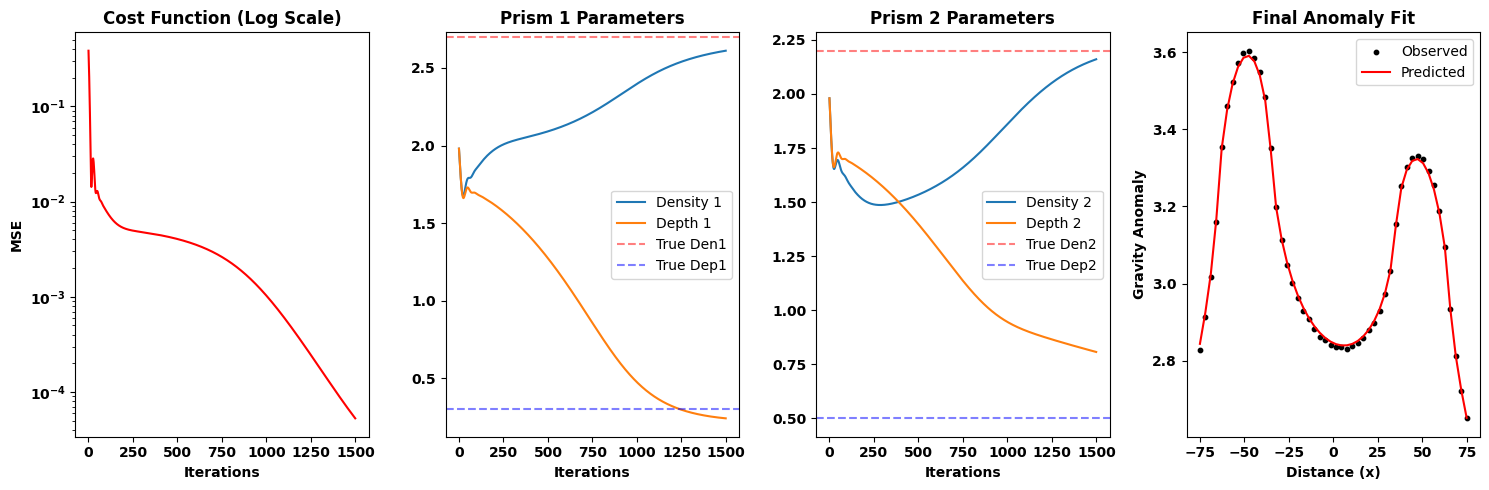


Results:
Prism 1: Den=2.611 (True=2.7), Dep=0.243 (True=0.3)
Prism 2: Den=2.160 (True=2.2), Dep=0.807 (True=0.5)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

# ==========================================
# 1. SYNTHETIC MODEL GENERATION (NumPy)
# ==========================================
G = 6.67 * (10**-6)
D1, d1, m1, rho1, A1 = 0.3, 0.001, 30.1, 2.7, -50.1
D2, d2, m2, rho2, A2 = 0.5, 0.001, 30.1, 2.2, 50.1

x_np = np.linspace(-75, 75, 50).astype(np.float32)

def forward_numpy(x, den, dep, A, m, d):
    # Using the exact same math as your original notebook
    r1 = (((x-A)+(0.5*m))**2)+((d)**2)
    r2 = (((x-A)+(0.5*m))**2)+((dep*1000)**2)
    r3 = (((x-A)-(0.5*m))**2)+((d)**2)
    r4 = (((x-A)-(0.5*m))**2)+((dep*1000)**2)
    f1 = np.arctan((x-A+(0.5*m))/(dep*1000)) - np.arctan((x-A-(0.5*m))/(dep*1000))
    f2 = np.arctan((x-A+(0.5*m))/d) - np.arctan((x-A-(0.5*m))/d)
    f3 = 0.5*(x-A)*(np.log10((r2*r3)/(r1*r4)))
    f4 = 0.25*m*(np.log10((r2*r4)/(r1*r3)))
    f = ((dep*1000)*f1) - (d*f2) + f3 + f4
    return 2*G*den*1000*f

y_true = forward_numpy(x_np, rho1, D1, A1, m1, d1) + forward_numpy(x_np, rho2, D2, A2, m2, d2)
# Adding some noise
y_true += np.random.normal(0, 0.002, size=x_np.shape)

# ==========================================
# 2. DIFFERENTIABLE FORWARD MODEL (TensorFlow)
# ==========================================
def forward_tf(x, den, dep, A, m, d):
    # Differentiable version of the prism formula
    A, m, d = tf.cast(A, tf.float32), tf.cast(m, tf.float32), tf.cast(d, tf.float32)
    D_m = dep * 1000.0

    r1 = tf.square(x - A + 0.5*m) + tf.square(d)
    r2 = tf.square(x - A + 0.5*m) + tf.square(D_m)
    r3 = tf.square(x - A - 0.5*m) + tf.square(d)
    r4 = tf.square(x - A - 0.5*m) + tf.square(D_m)

    f1 = tf.atan((x - A + 0.5*m) / D_m) - tf.atan((x - A - 0.5*m) / D_m)
    f2 = tf.atan((x - A + 0.5*m) / d) - tf.atan((x - A - 0.5*m) / d)

    # log10(x) = ln(x) / ln(10)
    ln10 = tf.math.log(10.0)
    f3 = 0.5 * (x - A) * (tf.math.log((r2 * r3) / (r1 * r4)) / ln10)
    f4 = 0.25 * m * (tf.math.log((r2 * r4) / (r1 * r3)) / ln10)

    f = (D_m * f1) - (d * f2) + f3 + f4
    return 2.0 * G * den * 1000.0 * f

# ==========================================
# 3. ADAM OPTIMIZER WITH AUTO-GRAD
# ==========================================
def run_inversion_adam(iterations=1000, lr=0.01):
    # Initialize variables as TensorFlow Trackables
    v_den1 = tf.Variable(2.0, dtype=tf.float32)
    v_dep1 = tf.Variable(2.0, dtype=tf.float32)
    v_den2 = tf.Variable(2.0, dtype=tf.float32)
    v_dep2 = tf.Variable(2.0, dtype=tf.float32)

    opt = tf.optimizers.Adam(learning_rate=lr)

    history = {'cost': [], 'den1': [], 'dep1': [], 'den2': [], 'dep2': []}
    x_tf = tf.convert_to_tensor(x_np, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_true, dtype=tf.float32)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            # Predict total signal
            y1_p = forward_tf(x_tf, v_den1, v_dep1, A1, m1, d1)
            y2_p = forward_tf(x_tf, v_den2, v_dep2, A2, m2, d2)
            y_p = y1_p + y2_p

            # Cost Function (MSE)
            loss = tf.reduce_mean(tf.square(y_tf - y_p))

        # Automatic Gradient Calculation
        grads = tape.gradient(loss, [v_den1, v_dep1, v_den2, v_dep2])
        opt.apply_gradients(zip(grads, [v_den1, v_dep1, v_den2, v_dep2]))

        # Save progress
        history['cost'].append(loss.numpy())
        history['den1'].append(v_den1.numpy())
        history['dep1'].append(v_dep1.numpy())
        history['den2'].append(v_den2.numpy())
        history['dep2'].append(v_dep2.numpy())

        if i % 200 == 0:
            print(f"Iteration {i}: Loss = {loss.numpy():.8f}")

    return history, (v_den1.numpy(), v_dep1.numpy(), v_den2.numpy(), v_dep2.numpy())

# Execute Inversion
hist, final_params = run_inversion_adam(iterations=1500, lr=0.02)
f_den1, f_dep1, f_den2, f_dep2 = final_params

# ==========================================
# 4. FINAL VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Cost Convergence
plt.subplot(1, 4, 1)
plt.plot(hist['cost'], color='red')
plt.yscale('log')
plt.title('Cost Function (Log Scale)',weight='bold')
plt.xlabel('Iterations',weight='bold')
plt.ylabel('MSE',weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
# Plot 2: Parameter Convergence (Prism 1)
plt.subplot(1, 4, 2)
plt.plot(hist['den1'], label='Density 1')
plt.plot(hist['dep1'], label='Depth 1')

plt.axhline(rho1, color='red', linestyle='--', alpha=0.5, label='True Den1')
plt.axhline(D1, color='blue', linestyle='--', alpha=0.5, label='True Dep1')

plt.title('Prism 1 Parameters',weight='bold')
plt.xlabel('Iterations',weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.legend()

# Plot 3: Parameter Convergence (Prism 2)
plt.subplot(1, 4, 3)
plt.plot(hist['den2'], label='Density 2')
plt.plot(hist['dep2'], label='Depth 2')
plt.axhline(rho2, color='red', linestyle='--', alpha=0.5, label='True Den2')
plt.axhline(D2, color='blue', linestyle='--', alpha=0.5, label='True Dep2')
plt.title('Prism 2 Parameters',weight='bold')
plt.xlabel('Iterations',weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.legend()


# Plot 4: Final Fit
plt.subplot(1, 4, 4)
y_final = forward_numpy(x_np, f_den1, f_dep1, A1, m1, d1) + forward_numpy(x_np, f_den2, f_dep2, A2, m2, d2)
plt.scatter(x_np, y_true, color='black', s=10, label='Observed')
plt.plot(x_np, y_final, color='red', label='Predicted')
plt.title('Final Anomaly Fit',weight='bold')
plt.xlabel('Distance (x)',weight='bold')
plt.ylabel('Gravity Anomaly',weight='bold')
plt.legend()
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"Prism 1: Den={f_den1:.3f} (True={rho1}), Dep={f_dep1:.3f} (True={D1})")
print(f"Prism 2: Den={f_den2:.3f} (True={rho2}), Dep={f_dep2:.3f} (True={D2})")

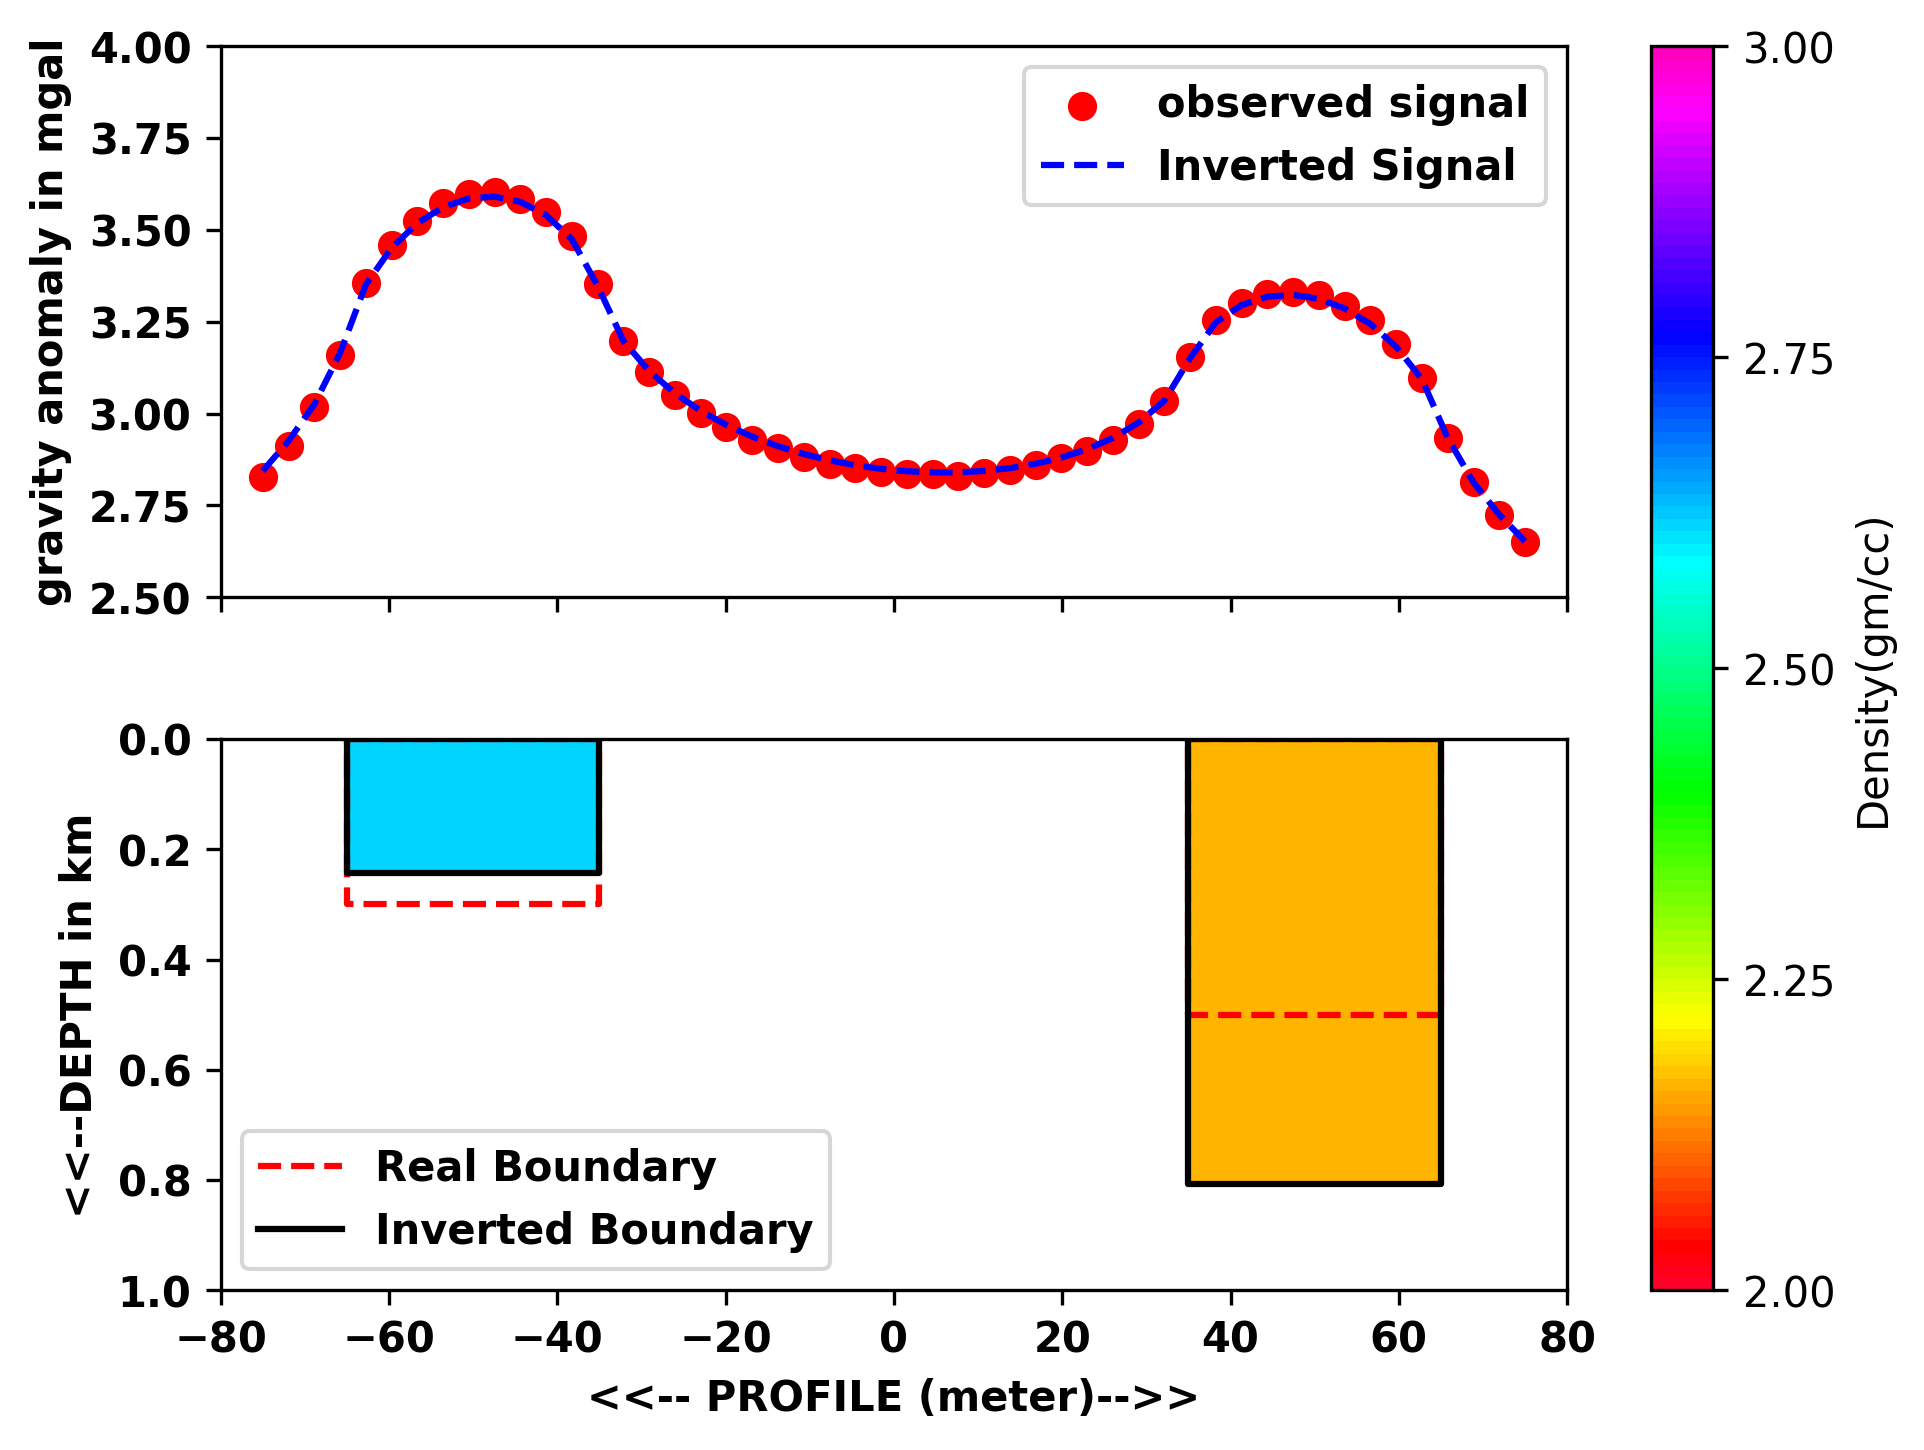

In [9]:
fig, axs = plt.subplots(2)
fig.dpi=300
fig.tight_layout(pad=1.3)
cmap_V= plt.get_cmap('gist_rainbow',100)
maximum_V=3#maximum density value in color scale in gm/cc
minimum_V=2#minimum density value in color scale in gm/cc
diff_V=(maximum_V - minimum_V)
color_index_V = np.linspace(minimum_V,maximum_V,10)

estimated_density1 = f_den1
estimated_depth1 = f_dep1
estimated_density2 = f_den2
estimated_depth2 = f_dep2
Y=y_true
Y_pred = y_final
X = x
#choosing the color depending upon the inverted density value of 1st prism
index_value_V1 = (estimated_density1-minimum_V)/diff_V
color_V1 = cmap_V(index_value_V1)
#choosing the color depending upon the inverted density value of 2nd prism
index_value_V2 = (estimated_density2-minimum_V)/diff_V
color_V2 = cmap_V(index_value_V2)
norm = mpl.colors.Normalize(vmin=minimum_V, vmax=3)
sm = plt.cm.ScalarMappable(cmap=cmap_V, norm=norm)
sm.set_array([])
#plotting colorscale
plt.colorbar(sm, ticks=np.linspace(minimum_V,maximum_V,5),ax=axs.ravel().tolist(),label='Density(gm/cc)')
axs[0].scatter(X, Y, marker='o', color='red') #observed anomaly
axs[0].plot(X,Y_pred, color='blue',markerfacecolor='red',markersize=10,linestyle='dashed') #reconstructed anomaly using estimated parameters
legend_properties = {'weight':'bold'}
axs[0].legend(['observed signal','Inverted Signal'],prop=legend_properties)
axs[0].set_ylabel("gravity anomaly in mgal",weight='bold',fontsize=10)
axs[0].set_xlim(-80,80)
axs[0].set_ylim(2.5,4)
plt.setp(axs[0].get_xticklabels(), visible= False)
plt.setp(axs[0].get_yticklabels(), weight='bold')
#creating a prism using 4 corner co-ordinates using inverted results
coord1 = [[-65,0], [-35,0], [-35,estimated_depth1], [-65,estimated_depth1]]
coord2 = [[35,0], [65,0], [65,estimated_depth2], [35,estimated_depth2]]
coord1.append(coord1[0]) #repeat the first point to create a 'closed loop'
coord2.append(coord2[0]) #repeat the first point to create a 'closed loop'
xs1, ys1 = zip(*coord1) #create lists of x and y values
xs2, ys2 = zip(*coord2) #create lists of x and y values
#creating a prism using 4 corner co-ordinates using real values
coord3 = [[-65,0], [-35,0], [-35,0.3], [-65,0.3]]
coord4 = [[35,0], [65,0], [65,0.5], [35,0.5]]
coord3.append(coord3[0]) #repeat the first point to create a 'closed loop'
coord4.append(coord4[0]) #repeat the first point to create a 'closed loop'
xs3, ys3 = zip(*coord3) #create lists of x and y values
xs4, ys4 = zip(*coord4) #create lists of x and y values
axs[1].plot(xs3,ys3,'red',linestyle='dashed')#plotting prism1 using real values
axs[1].plot(xs1,ys1,'k')#plotting prism1 using inverted values
axs[1].fill(xs1, ys1, facecolor=color_V1)#color filling inverted prism1 with inverted density value of prism 1
axs[1].plot(xs4,ys4,'red',linestyle='dashed')#plotting prism2 using real values
axs[1].plot(xs2,ys2,'k')#plotting prism2 using inverted values
axs[1].fill(xs2, ys2, facecolor=color_V2)#color filling inverted prism1 with inverted density value of prism 2
axs[1].set_xlim(-80,80)
axs[1].set_ylim(1,0)
legend_properties = {'weight':'bold'}
axs[1].legend(['Real Boundary','Inverted Boundary'],prop=legend_properties)
axs[1].set_xlabel('<<-- PROFILE (meter)-->>',fontsize=10,weight='bold')
axs[1].set_ylabel("<<--DEPTH in km",fontsize=10,weight='bold')
#axs[1].set_xticks(weight='bold')
plt.setp(axs[1].get_xticklabels(), weight= 'bold')
plt.setp(axs[1].get_yticklabels(), weight= 'bold')
plt.show()
